In [ ]:
!pip install timm scikit-learn

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import timm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
!unzip "/content/drive/MyDrive/Mini Project/archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: CheXpert-v1.0-small/train/patient60445/study2/view1_frontal.jpg  
  inflating: CheXpert-v1.0-small/train/patient60445/study2/view2_lateral.jpg  
  inflating: CheXpert-v1.0-small/train/patient60446/study1/view1_frontal.jpg  
  inflating: CheXpert-v1.0-small/train/patient60446/study2/view1_frontal.jpg  
  inflating: CheXpert-v1.0-small/train/patient60446/study2/view2_lateral.jpg  
  inflating: CheXpert-v1.0-small/train/patient60447/study1/view1_frontal.jpg  
  inflating: CheXpert-v1.0-small/train/patient60447/study1/view2_lateral.jpg  
  inflating: CheXpert-v1.0-small/train/patient60448/study1/view1_frontal.jpg  
  inflating: CheXpert-v1.0-small/train/patient60448/study1/view2_lateral.jpg  
  inflating: CheXpert-v1.0-small/train/patient60448/study1/view3_lateral.jpg  
  inflating: CheXpert-v1.0-small/train/patient60449/study1/view1_frontal.jpg  
  inflating: CheXpert-v1.0-small/train/patient60449/study1/view2_lateral.jpg  
 

# 1) Reading Dataset


In [ ]:
csv_path="/content/CheXpert-v1.0-small/train.csv"
image_root = "/content/CheXpert-v1.0-small/"

df=pd.read_csv(csv_path)
df.head(5)

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


# 2)Reducing dataframe to 4 classes

In [ ]:
import pandas as pd

# List of disease columns
DISEASES = ["Pneumonia", "Cardiomegaly", "Pleural Effusion", "Pneumothorax"]

# Step 1: Keep rows where at least one disease is labeled
df = df.dropna(subset=DISEASES, how='all')

# Step 2: Drop rows with uncertain labels (-1)
df = df[(df[DISEASES] != -1).all(axis=1)]

# Step 3: Define function to assign single-class label
def assign_class(row):
    positives = [d for d in DISEASES if row[d] == 1]

    if len(positives) == 0:
        return 0  # Normal
    if len(positives) == 1:
        return DISEASES.index(positives[0]) + 1  # Single disease
    return None  # Multiple diseases → drop

# Step 4: Apply function to create 'label' column
df["label"] = df.apply(assign_class, axis=1)

# Step 5: Drop rows with multiple positives (None labels)
df = df.dropna(subset=["label"])

# Step 6: Convert label column to integer
df["label"] = df["label"].astype(int)

# Optional: Check final distribution
print(df["label"].value_counts())


label
3    57437
0    51173
2    11782
4    11174
1     3580
Name: count, dtype: int64


In [ ]:
samples_per_disease=10000

disease_dfs=[]

for disease in DISEASES:
  disease_df=df[df[disease]==1]
  disease_df=disease_df.sample(n=min(samples_per_disease,len(disease_df)),random_state=42)
  disease_dfs.append(disease_df)
  print(f"{disease}: {len(disease_df)} samples")

Pneumonia: 3580 samples
Cardiomegaly: 10000 samples
Pleural Effusion: 10000 samples
Pneumothorax: 10000 samples


In [ ]:
NORMAL_SAMPLES = 15000

normal_df = df[
    (df["No Finding"] == 1) &
    (df[DISEASES].sum(axis=1) == 0)
]

normal_df = normal_df.sample(
    n=min(NORMAL_SAMPLES, len(normal_df)),
    random_state=42
)

print("Normal:", len(normal_df))

Normal: 15000


In [ ]:
final_df = pd.concat(disease_dfs + [normal_df]).drop_duplicates()

print("Final dataset size:", final_df.shape)
final_df.head()

Final dataset size: (48580, 20)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,label
75262,CheXpert-v1.0-small/train/patient18073/study7/...,Female,61,Frontal,PA,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,1
22245,CheXpert-v1.0-small/train/patient05427/study1/...,Male,76,Lateral,NaN,NaN,NaN,NaN,-1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1
42689,CheXpert-v1.0-small/train/patient10459/study1/...,Male,64,Lateral,NaN,NaN,0.0,NaN,NaN,1.0,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1
183541,CheXpert-v1.0-small/train/patient43374/study1/...,Female,90,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1
85243,CheXpert-v1.0-small/train/patient20474/study7/...,Male,25,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1


# 3) Reducing the dataframe to desired columns

In [ ]:
balanced_df=final_df[['Path','Sex','Age','Frontal/Lateral','AP/PA','label']]
balanced_df['label'].value_counts()

,count
label,
0,15000
3,10000
2,10000
4,10000
1,3580


## 4) Splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    stratify=balanced_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

34006 7287 7287


# 5) CustomDataset class

In [ ]:

import os
import torch
from torch.utils.data import Dataset
from PIL import Image

class CheXpertDataset(Dataset):
    def __init__(self, dataframe, image_root, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_root, row["Path"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label






# 6) Transform and Data Augmentaion

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

## 7) Custom data objects

In [ ]:
IMAGE_ROOT='/content/'

train_dataset=CheXpertDataset(
    train_df,
    IMAGE_ROOT,
    train_transform
)

val_dataset=CheXpertDataset(
    val_df,
    IMAGE_ROOT,
    val_transform
)

test_dataset=CheXpertDataset(
    test_df,
    IMAGE_ROOT,
    val_transform
)


## 8) Creating a  dataloader

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,#multiple processers

)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,

)

test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

#9) Class weights

In [ ]:
total_samples = len(train_df)
num_classes = 5

class_counts = train_df["label"].value_counts().sort_index().values

class_weights = total_samples / (num_classes * torch.tensor(class_counts, dtype=torch.float))
class_weights = class_weights.to(device)

print(class_weights)

tensor([0.6477, 2.7140, 0.9716, 0.9716, 0.9716], device='cuda:0')


# 10) Random Hyperparameter search setup

In [ ]:
learning_rates = [1e-3, 5e-4, 1e-4]
weight_decays  = [1e-4, 1e-5]
batch_sizes    = [16, 32]
num_trials = 5
epochs = 7

## 11) Training and validation function

In [ ]:
lr = 1e-4
weight_decay = 1e-4
batch_size = 32
epochs = 10
patience = 3

In [ ]:
from tqdm import tqdm

def train_model():

    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=5
    )
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_val_auc = 0
    trigger = 0

    for epoch in range(epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")

        for images, labels in train_bar:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

            train_bar.set_postfix(loss=loss.item())

        train_acc = accuracy_score(train_labels, train_preds)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []
        val_probs = []

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]")

        with torch.no_grad():

            for images, labels in val_bar:

                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                probs = torch.softmax(outputs, dim=1)

                val_probs.extend(probs.cpu().numpy())
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        val_acc = accuracy_score(val_labels, val_preds)

        val_labels_bin = label_binarize(val_labels, classes=[0,1,2,3,4])
        val_auc = roc_auc_score(val_labels_bin, val_probs, average="macro")

        scheduler.step()

        print(f"\nEpoch {epoch+1}")
        print(f"Train Acc: {train_acc:.4f}")
        print(f"Val Acc:   {val_acc:.4f}")
        print(f"Val AUC:   {val_auc:.4f}")

        # ------------------ EARLY STOPPING ------------------
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), "best_model.pth")
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print("Early stopping triggered")
                break

    print("\nBest Validation AUC:", best_val_auc)

    return best_val_auc

In [ ]:
best_auc = train_model()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/10 [Validation]: 100%|██████████| 228/228 [01:24<00:00,  2.71it/s, loss=1.48]



Epoch 1
Train Acc: 0.4273
Val Acc:   0.4522
Val AUC:   0.8100


Epoch 2/10 [Validation]: 100%|██████████| 228/228 [01:24<00:00,  2.71it/s, loss=1.02]


...


Epoch 8
Train Acc: 0.7181
Val Acc:   0.6344
Val AUC:   0.8630


Epoch 9/10 [Validation]: 100%|██████████| 228/228 [01:23<00:00,  2.72it/s, loss=1.39]



Epoch 9
Train Acc: 0.7498
Val Acc:   0.6458
Val AUC:   0.8651


Epoch 10/10 [Training]:   1%|          | 12/1063 [00:14<20:55,  1.19s/it, loss=0.685]


KeyboardInterrupt: 

## 12) Load Best Model

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Load model
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=5
)

model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 13) Final Test Evaluation

In [ ]:
test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Accuracy
test_acc = accuracy_score(test_labels, test_preds)

# Macro AUC
test_labels_bin = label_binarize(test_labels, classes=[0,1,2,3,4])
test_auc = roc_auc_score(test_labels_bin, test_probs, average="macro")

print("Test Accuracy:", test_acc)
print("Test Macro AUC:", test_auc)

Test Accuracy: 0.6430629888843146
Test Macro AUC: 0.8672586396732023


## 14) Confusion Matrix

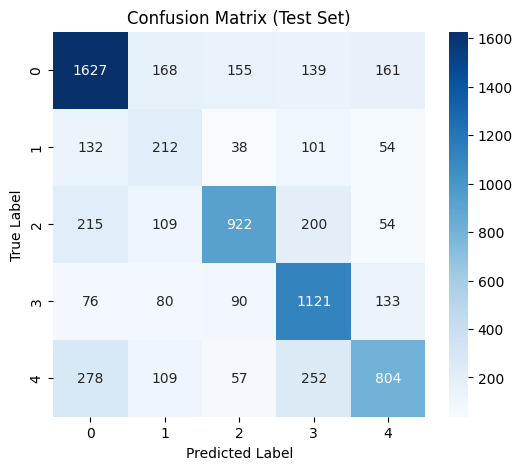

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.show()

##15) Per-Class AUC

In [ ]:
for i in range(5):
    auc_score = roc_auc_score(
        test_labels_bin[:, i],
        np.array(test_probs)[:, i]
    )
    print(f"Class {i} AUC: {auc_score:.4f}")

Class 0 AUC: 0.8762
Class 1 AUC: 0.8001
Class 2 AUC: 0.8920
Class 3 AUC: 0.9033
Class 4 AUC: 0.8647


## 16) ROC Curves Plot

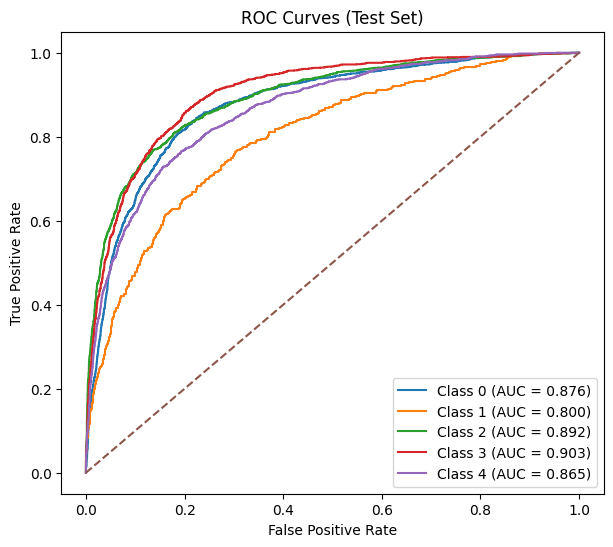

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(
        test_labels_bin[:, i],
        np.array(test_probs)[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.show()

## 17) classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71      2250
           1       0.31      0.39      0.35       537
           2       0.73      0.61      0.67      1500
           3       0.62      0.75      0.68      1500
           4       0.67      0.54      0.59      1500

    accuracy                           0.64      7287
   macro avg       0.61      0.60      0.60      7287
weighted avg       0.65      0.64      0.64      7287

